## Website:Flipkart
- Website URL
- url="https://www.flipkart.com/search?q=telivisions&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off"

# **Step1: Problem Statement**

- **To analyze TV market data and understand how price varies across different TV features.**

- **Study the impact of screen size, resolution, and display type on TV pricing.**

- **To examine customer ratings and reviews to identify popular TV models.**

- **To provide useful insights for buyers and sellers to support better purchasing and marketing decisions**.

# **Step2: Data Collection**

##  Importing required libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import re
import requests
from bs4 import BeautifulSoup
import time

In [38]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
# BASE URL
url = "https://www.flipkart.com/search?q=telivisions&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off"

In [7]:
response=requests.get(url)

In [8]:
response ## Status code 200 indicates the request was successful

<Response [200]>

#### Observations: 
- Status code 200 indicates that the request was processed successfully and the response was returned correctly.

## **Web Scrapping**

In [9]:
productName = [] 
prices = []
rating = []
features = []
pagenum = []
original_price = []
Discount = []
Review = []

total_time = time.time()

for i in range(1,83): 
    start_time = time.time()
    URL=f"https://www.flipkart.com/search?q=telivisions&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off%22%60&page={i}"
    page = requests.get(URL)
    soup = BeautifulSoup(page.text, "html.parser") #BeautifulSoup used to convert webpage HTML into a readable structure for web scraping.

    for x in soup.find_all('div', attrs={'class':"ZFwe0M row"}):
        
        pname = x.find("div", attrs={'class':"RG5Slk"})
        productName.append(pname.text if pname else np.nan)
        
        feat = x.find("div", attrs={'class':"CMXw7N"})
        features.append(feat.text if feat else np.nan)
        
        price = x.find("div", attrs={'class':"hZ3P6w DeU9vF"})
        prices.append(price.text if price else np.nan)
        
        op = x.find("div", attrs={'class':"kRYCnD gxR4EY"})
        original_price.append(op.text if op else np.nan)
        
        disc = x.find("div", attrs={'class':"HQe8jr"})
        Discount.append(disc.text if disc else np.nan)
        
        rat = x.find("div", attrs={'class':"MKiFS6"})
        rating.append(rat.text if rat else np.nan)
        
        review = x.find("span", attrs={'class':"PvbNMB"})
        Review.append(review.text if review else np.nan)
        
        pagenum.append(i)

    print(f'Page {i} scrapped in {time.time()-start_time:.2f} seconds')

print("Total Time Completed in seconds", str(time.time()-total_time))

Page 1 scrapped in 0.88 seconds
Page 2 scrapped in 0.56 seconds
Page 3 scrapped in 0.55 seconds
Page 4 scrapped in 0.81 seconds
Page 5 scrapped in 0.57 seconds
Page 6 scrapped in 0.79 seconds
Page 7 scrapped in 0.61 seconds
Page 8 scrapped in 0.86 seconds
Page 9 scrapped in 0.87 seconds
Page 10 scrapped in 0.71 seconds
Page 11 scrapped in 0.69 seconds
Page 12 scrapped in 0.85 seconds
Page 13 scrapped in 0.81 seconds
Page 14 scrapped in 0.72 seconds
Page 15 scrapped in 0.71 seconds
Page 16 scrapped in 0.71 seconds
Page 17 scrapped in 0.49 seconds
Page 18 scrapped in 0.74 seconds
Page 19 scrapped in 0.47 seconds
Page 20 scrapped in 0.56 seconds
Page 21 scrapped in 0.70 seconds
Page 22 scrapped in 0.49 seconds
Page 23 scrapped in 0.56 seconds
Page 24 scrapped in 0.54 seconds
Page 25 scrapped in 0.52 seconds
Page 26 scrapped in 0.68 seconds
Page 27 scrapped in 0.53 seconds
Page 28 scrapped in 1.03 seconds
Page 29 scrapped in 0.67 seconds
Page 30 scrapped in 0.53 seconds
Page 31 scrapped in

In [10]:
tv = pd.DataFrame({"PageNum":pagenum,"ProductName": productName,"Price(₹)":prices,"Original_Price(₹)": original_price,"Discount(%)": Discount,"Rating": rating,"Review": Review,"Features": features})

In [11]:
#DataFrame Before cleaning
tv

,PageNum,ProductName,Price(₹),Original_Price(₹),Discount(%),Rating,Review,Features
0,1,Samsung 138 cm (55 inch) QLED Ultra HD (4K) Sm...,"₹44,990","₹75,500",40% off,4.2,"3,225 Ratings & 202 Reviews",Ultra HD (4K) | QLEDModel ID: QA55QEF6AULXLLau...
1,1,Samsung Crystal 4K Infinity Vision 108 cm (43 ...,"₹26,490","₹41,300",35% off,4.3,"71,869 Ratings & 4,754 Reviews",Ultra HD (4K) | LEDModel ID: UA43UE84AFULXLLau...
2,1,MarQ by Flipkart 60 cm (24 inch) HD Ready LED TV,"₹4,099","₹15,000",72% off,4.2,"11,465 Ratings & 849 Reviews",HD Ready | LEDModel ID: 24HDNDQEETBLaunch Year...
3,1,realme TechLife 80 cm (32 inch) QLED HD Ready ...,"₹9,299","₹23,999",61% off,4.3,"21,220 Ratings & 1,628 Reviews",HD Ready | QLEDModel ID: 32HDGQRDDAQLaunch Yea...
4,1,Coocaa S4U Pro 80 cm (32 inch) HD Ready LED Sm...,"₹7,699","₹13,999",45% off,4.2,"21,336 Ratings & 2,551 Reviews",HD Ready | LEDModel ID: 32S4U ProLaunch Year: ...
...,...,...,...,...,...,...,...,...
979,41,Acer 108 cm (43 inch) Ultra HD (4K) LED Smart ...,"₹22,990","₹42,990",46% off,4,215 Ratings & 17 Reviews,Ultra HD (4K) | LEDModel ID: AR43GT2851UDFLLau...
980,41,Wobble X Series 108 cm (43 inch) QLED Ultra HD...,"₹21,999","₹50,999",56% off,NaN,NaN,Ultra HD (4K) | QLEDModel ID: WB43QDXGU2875T24...
981,41,Samsung Crystal 4K Infinity Vision 138 cm (55 ...,"₹39,490","₹57,000",30% off,4.3,"71,869 Ratings & 4,754 Reviews",Ultra HD (4K) | LEDModel ID: UA55UE84AFULXLLau...
982,41,LG AI TV UR7500 108 cm (43 inch) Ultra HD (4K)...,"₹37,129","₹49,990",25% off,4.4,"36,969 Ratings & 2,497 Reviews",Ultra HD (4K) | LEDModel ID: 43UR75006LCLaunch...


### **Saving the data to csv file**

In [12]:
tv.to_csv("tv.csv",index=False)

# **Step 3:Data Cleaning**

### **Loading the Dataset**

In [85]:
tv=pd.read_csv("tv.csv")
tv

,PageNum,ProductName,Price(₹),Original_Price(₹),Discount(%),Rating,Review,Features
0,1,Samsung 138 cm (55 inch) QLED Ultra HD (4K) Sm...,"₹44,990","₹75,500",40% off,4.2,"3,225 Ratings & 202 Reviews",Ultra HD (4K) | QLEDModel ID: QA55QEF6AULXLLau...
1,1,Samsung Crystal 4K Infinity Vision 108 cm (43 ...,"₹26,490","₹41,300",35% off,4.3,"71,869 Ratings & 4,754 Reviews",Ultra HD (4K) | LEDModel ID: UA43UE84AFULXLLau...
2,1,MarQ by Flipkart 60 cm (24 inch) HD Ready LED TV,"₹4,099","₹15,000",72% off,4.2,"11,465 Ratings & 849 Reviews",HD Ready | LEDModel ID: 24HDNDQEETBLaunch Year...
3,1,realme TechLife 80 cm (32 inch) QLED HD Ready ...,"₹9,299","₹23,999",61% off,4.3,"21,220 Ratings & 1,628 Reviews",HD Ready | QLEDModel ID: 32HDGQRDDAQLaunch Yea...
4,1,Coocaa S4U Pro 80 cm (32 inch) HD Ready LED Sm...,"₹7,699","₹13,999",45% off,4.2,"21,336 Ratings & 2,551 Reviews",HD Ready | LEDModel ID: 32S4U ProLaunch Year: ...
...,...,...,...,...,...,...,...,...
979,41,Acer 108 cm (43 inch) Ultra HD (4K) LED Smart ...,"₹22,990","₹42,990",46% off,4.0,215 Ratings & 17 Reviews,Ultra HD (4K) | LEDModel ID: AR43GT2851UDFLLau...
980,41,Wobble X Series 108 cm (43 inch) QLED Ultra HD...,"₹21,999","₹50,999",56% off,NaN,NaN,Ultra HD (4K) | QLEDModel ID: WB43QDXGU2875T24...
981,41,Samsung Crystal 4K Infinity Vision 138 cm (55 ...,"₹39,490","₹57,000",30% off,4.3,"71,869 Ratings & 4,754 Reviews",Ultra HD (4K) | LEDModel ID: UA55UE84AFULXLLau...
982,41,LG AI TV UR7500 108 cm (43 inch) Ultra HD (4K)...,"₹37,129","₹49,990",25% off,4.4,"36,969 Ratings & 2,497 Reviews",Ultra HD (4K) | LEDModel ID: 43UR75006LCLaunch...


In [86]:
#Checking the shape of the dataframe
tv.shape

(984, 8)

In [87]:
# Shows a quick summary of the DataFrame
tv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PageNum            984 non-null    int64  
 1   ProductName        984 non-null    object 
 2   Price(₹)           984 non-null    object 
 3   Original_Price(₹)  982 non-null    object 
 4   Discount(%)        981 non-null    object 
 5   Rating             812 non-null    float64
 6   Review             812 non-null    object 
 7   Features           979 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 61.6+ KB


In [88]:
#checking the null values
tv.isnull().sum()

PageNum                0
ProductName            0
Price(₹)               0
Original_Price(₹)      2
Discount(%)            3
Rating               172
Review               172
Features               5
dtype: int64

### **Handling Null Values**

In [89]:
tv["Original_Price(₹)"].fillna(tv["Original_Price(₹)"].mode()[0],inplace = True)
tv["Price(₹)"].fillna(tv["Price(₹)"].mode()[0],inplace = True)
tv["Discount(%)"].fillna(tv["Discount(%)"].mode()[0],inplace = True)
tv["Rating"].fillna(tv["Rating"].mode()[0],inplace = True)
tv["Review"].fillna(tv["Review"].mode()[0],inplace = True)
tv["Features"].fillna(tv["Features"].mode()[0],inplace = True)

In [90]:
tv.isnull().sum()

PageNum              0
ProductName          0
Price(₹)             0
Original_Price(₹)    0
Discount(%)          0
Rating               0
Review               0
Features             0
dtype: int64

### **Checking Duplicates**

In [91]:
tv.duplicated().sum()

np.int64(0)

In [92]:
# Brand
tv["Brand"] = tv["ProductName"].apply(lambda x:re.findall(r"^\w+",x)[0])

# Screen Size
tv['Screen_Size_inch']= tv['ProductName'].str.extract(r'(\d{2}\.?\d?\s?inch)'.replace('inch',''))
tv['Screen_Size_inch'].fillna(tv["Screen_Size_inch"].mode()[0],inplace = True)

# Sound Watt
tv['Screen_Size_inch']= tv['ProductName'].str.extract(r'(\d{2}\.?\d?\s?inch)'.replace('inch',''))
tv['Screen_Size_inch'].fillna(tv["Screen_Size_inch"].mode()[0],inplace = True)

#Year
tv['Year'] = tv['Features'].str.findall(r'20\d{2}').str[0]
tv["Year"].fillna(tv["Year"].mode()[0],inplace = True)

# no.of Ratings
tv["Ratings"] = tv["Review"].apply(lambda x: re.split(r"[&]",x)[0])
tv["no_of_ratings"] = tv["Ratings"].apply(lambda x: re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

# no.of reviews
tv["Reviews"] =  tv["Review"].apply(lambda x: re.split(r"[&]",x)[1])
tv["no_of_Reviews"] = tv["Reviews"].apply(lambda x: re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

# Warranty
tv['Warranty'] = tv['Features'].astype(str).apply(lambda x: (re.findall(r'(\d+)\s*Year', x) or [np.nan])[0])
tv["Warranty"].fillna(tv["Warranty"].mode()[0],inplace = True)

#Resolution
tv['Resolution'] = tv['ProductName'].apply(lambda x: (re.findall(r'Ultra HD|Full HD|HD Ready|4K|HD', x) or [np.nan])[0])
tv["Resolution"].fillna(tv["Resolution"].mode()[0],inplace = True)

# Discount
tv["Discount(%)"] = tv["Discount(%)"].apply(lambda x: re.findall(r"[\d%]+",x)[0])

#Sound watt
tv['Sound_Watt'] = tv['Features'].apply(lambda x: (re.findall(r'(\d+)\s*W', x) or [np.nan])[0])
tv['Sound_Watt'].fillna(tv["Sound_Watt"].mode()[0],inplace = True)

In [93]:
tv.shape

(984, 18)

In [94]:
## Dropping the Unnecessary columns
tv.drop(columns=['ProductName','Review','Features','Ratings','Reviews'],inplace=True)

In [95]:
tv

,PageNum,Price(₹),Original_Price(₹),Discount(%),Rating,Brand,Screen_Size_inch,Year,no_of_ratings,no_of_Reviews,Warranty,Resolution,Sound_Watt
0,1,"₹44,990","₹75,500",40%,4.2,Samsung,138,2025,3225,202,2,Ultra HD,20
1,1,"₹26,490","₹41,300",35%,4.3,Samsung,108,2025,71869,4754,2,4K,20
2,1,"₹4,099","₹15,000",72%,4.2,MarQ,60,2024,11465,849,1,HD Ready,20
3,1,"₹9,299","₹23,999",61%,4.3,realme,80,2025,21220,1628,1,HD Ready,26
4,1,"₹7,699","₹13,999",45%,4.2,Coocaa,80,2025,21336,2551,1,HD Ready,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,41,"₹22,990","₹42,990",46%,4.0,Acer,108,2024,215,17,2,Ultra HD,24
980,41,"₹21,999","₹50,999",56%,4.1,Wobble,108,2024,2355,335,1,Ultra HD,80
981,41,"₹39,490","₹57,000",30%,4.3,Samsung,138,2025,71869,4754,2,4K,20
982,41,"₹37,129","₹49,990",25%,4.4,LG,750,2025,36969,2497,1,Ultra HD,20


### **Null Percentage**

In [96]:
null_per=(tv.isnull().sum()/len(tv))*100
null_per

PageNum              0.0
Price(₹)             0.0
Original_Price(₹)    0.0
Discount(%)          0.0
Rating               0.0
Brand                0.0
Screen_Size_inch     0.0
Year                 0.0
no_of_ratings        0.0
no_of_Reviews        0.0
Warranty             0.0
Resolution           0.0
Sound_Watt           0.0
dtype: float64

### **Removing Special Characters**

In [97]:
tv["Price(₹)"] = tv["Price(₹)"].apply(lambda x: re.sub(r"[₹,]","",x)).astype("int")
tv["Original_Price(₹)"] = tv["Original_Price(₹)"].apply(lambda x: re.sub(r"[₹,]","",x)).astype("int")

### **Understanding Categorical columns**

In [98]:
for col in tv.columns:
    print(f"\nColumn: {col}")
    print(tv[col].value_counts(dropna=False))


Column: PageNum
PageNum
1     24
2     24
3     24
4     24
5     24
6     24
7     24
8     24
9     24
10    24
11    24
12    24
13    24
14    24
15    24
16    24
17    24
18    24
19    24
20    24
21    24
22    24
23    24
24    24
25    24
26    24
27    24
28    24
29    24
30    24
31    24
32    24
33    24
34    24
35    24
36    24
37    24
38    24
39    24
40    24
41    24
Name: count, dtype: int64

Column: Price(₹)
Price(₹)
26999    42
23999    40
7699     39
32999    27
22999    27
         ..
17390     1
64990     1
28283     1
67288     1
85118     1
Name: count, Length: 336, dtype: int64

Column: Original_Price(₹)
Original_Price(₹)
26999     46
54999     44
13999     39
32999     39
2098      30
          ..
147400     1
16990      1
96900      1
144900     1
27500      1
Name: count, Length: 269, dtype: int64

Column: Discount(%)
Discount(%)
18%    60
34%    56
45%    48
58%    48
51%    43
       ..
9%      1
76%     1
24%     1
12%     1
7%      1
Name: count,

In [99]:
cols = [col for col in tv.columns if col not in ['Rating', 'Original_Price(₹)', 'Discount(%)','Price(₹)']] \
       + ['Rating', 'Original_Price(₹)', 'Discount(%)','Price(₹)']
tv = tv[cols]
tv.head()

,PageNum,Brand,Screen_Size_inch,Year,no_of_ratings,no_of_Reviews,Warranty,Resolution,Sound_Watt,Rating,Original_Price(₹),Discount(%),Price(₹)
0,1,Samsung,138,2025,3225,202,2,Ultra HD,20,4.2,75500,40%,44990
1,1,Samsung,108,2025,71869,4754,2,4K,20,4.3,41300,35%,26490
2,1,MarQ,60,2024,11465,849,1,HD Ready,20,4.2,15000,72%,4099
3,1,realme,80,2025,21220,1628,1,HD Ready,26,4.3,23999,61%,9299
4,1,Coocaa,80,2025,21336,2551,1,HD Ready,20,4.2,13999,45%,7699


### **Converting the Datatypes**

In [100]:
tv.dtypes

PageNum                int64
Brand                 object
Screen_Size_inch      object
Year                  object
no_of_ratings          int64
no_of_Reviews          int64
Warranty              object
Resolution            object
Sound_Watt            object
Rating               float64
Original_Price(₹)      int64
Discount(%)           object
Price(₹)               int64
dtype: object

In [101]:
tv= tv.astype({'Warranty':int,'Screen_Size_inch':float,'Year':int,'Sound_Watt':int,'Discount(%)': 'category','Resolution':'category','Brand':'category'})

In [102]:
tv.dtypes

PageNum                 int64
Brand                category
Screen_Size_inch      float64
Year                    int64
no_of_ratings           int64
no_of_Reviews           int64
Warranty                int64
Resolution           category
Sound_Watt              int64
Rating                float64
Original_Price(₹)       int64
Discount(%)          category
Price(₹)                int64
dtype: object

In [103]:
tv

,PageNum,Brand,Screen_Size_inch,Year,no_of_ratings,no_of_Reviews,Warranty,Resolution,Sound_Watt,Rating,Original_Price(₹),Discount(%),Price(₹)
0,1,Samsung,138.0,2025,3225,202,2,Ultra HD,20,4.2,75500,40%,44990
1,1,Samsung,108.0,2025,71869,4754,2,4K,20,4.3,41300,35%,26490
2,1,MarQ,60.0,2024,11465,849,1,HD Ready,20,4.2,15000,72%,4099
3,1,realme,80.0,2025,21220,1628,1,HD Ready,26,4.3,23999,61%,9299
4,1,Coocaa,80.0,2025,21336,2551,1,HD Ready,20,4.2,13999,45%,7699
...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,41,Acer,108.0,2024,215,17,2,Ultra HD,24,4.0,42990,46%,22990
980,41,Wobble,108.0,2024,2355,335,1,Ultra HD,80,4.1,50999,56%,21999
981,41,Samsung,138.0,2025,71869,4754,2,4K,20,4.3,57000,30%,39490
982,41,LG,750.0,2025,36969,2497,1,Ultra HD,20,4.4,49990,25%,37129


# **Step 4:Data Manipulation**

In [104]:
# Shows statistical summary of all numeric columns in the dataset
tv.describe()

,PageNum,Screen_Size_inch,Year,no_of_ratings,no_of_Reviews,Warranty,Sound_Watt,Rating,Original_Price(₹),Price(₹)
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,21.000000,142.429167,2024.308943,11580.422764,1166.971545,1.239837,28.972561,4.136890,61896.805894,33679.982724
std,11.838176,118.889901,1.559300,21722.264625,2224.582602,0.427201,20.735172,0.321414,71273.639000,36966.697242
min,1.000000,10.000000,2006.000000,3.000000,0.000000,1.000000,2.000000,1.000000,599.000000,209.000000
25%,11.000000,80.000000,2024.000000,1229.000000,119.000000,1.000000,20.000000,4.100000,22990.000000,11946.250000
50%,21.000000,108.000000,2025.000000,2355.000000,335.000000,1.000000,20.000000,4.100000,44999.000000,25990.000000
75%,31.000000,139.000000,2025.000000,9690.500000,1146.000000,1.000000,30.000000,4.300000,71240.000000,39599.000000
max,41.000000,900.000000,2026.000000,131140.000000,21899.000000,2.000000,300.000000,5.000000,629999.000000,466667.000000


In [105]:
#Premium TVs (High price)
tv.sort_values(by='Price(₹)', ascending=False).head(5)

,PageNum,Brand,Screen_Size_inch,Year,no_of_ratings,no_of_Reviews,Warranty,Resolution,Sound_Watt,Rating,Original_Price(₹),Discount(%),Price(₹)
612,26,Samsung,214.0,2025,2355,335,2,Ultra HD,60,4.1,580600,19%,466667
874,37,Hisense,100.0,2025,211,23,2,Ultra HD,61,4.2,449999,40%,269479
908,38,Samsung,138.0,2017,6,1,1,Ultra HD,60,4.2,317900,19%,255699
915,39,Samsung,138.0,2017,6,1,1,Ultra HD,60,4.2,317900,19%,255699
794,34,TOSHIBA,253.0,2024,5528,831,2,Ultra HD,50,4.3,629999,61%,243999


In [106]:
#TVs with highest sound output
tv.sort_values(by='Sound_Watt', ascending=False).head(5)

,PageNum,Brand,Screen_Size_inch,Year,no_of_ratings,no_of_Reviews,Warranty,Resolution,Sound_Watt,Rating,Original_Price(₹),Discount(%),Price(₹)
779,33,TCL,300.0,2025,17,4,2,Ultra HD,300,4.2,229990,60%,89990
762,32,TCL,300.0,2025,17,4,2,Ultra HD,300,4.2,429990,69%,129990
737,31,TCL,300.0,2025,17,4,2,Ultra HD,300,4.2,429990,69%,129990
635,27,Thomson,164.0,2025,91,25,1,Ultra HD,108,4.3,86999,33%,57999
914,39,Blaupunkt,189.0,2025,55,13,1,Ultra HD,108,4.3,149999,36%,94999


In [107]:
# Top Companies by Reviews
tv.sort_values("no_of_Reviews", ascending=False).head(10)

,PageNum,Brand,Screen_Size_inch,Year,no_of_ratings,no_of_Reviews,Warranty,Resolution,Sound_Watt,Rating,Original_Price(₹),Discount(%),Price(₹)
663,28,Thomson,80.0,2020,128705,21899,1,HD Ready,24,4.3,14499,41%,8499
128,6,Thomson,80.0,2023,128705,21899,1,HD Ready,30,4.3,17999,44%,9999
112,5,Thomson,108.0,2023,128705,21899,1,Full HD,30,4.3,26999,40%,15999
314,14,Thomson,80.0,2020,128705,21899,1,HD Ready,24,4.3,14499,41%,8499
138,6,Thomson,108.0,2023,128705,21899,1,Full HD,30,4.3,26999,40%,15999
714,30,Thomson,189.0,2020,40745,9575,1,Ultra HD,30,4.4,149999,57%,63608
408,18,iFFALCON,64.0,2024,80266,8500,1,Ultra HD,24,4.2,50990,67%,16599
703,30,iFFALCON,62.0,2022,80266,8500,1,Ultra HD,24,4.2,60990,69%,18399
633,27,Samsung,80.0,2022,131140,7783,1,HD Ready,20,4.3,18900,31%,12999
309,13,Samsung,80.0,2022,131140,7783,1,HD Ready,20,4.3,18900,31%,12999


## **Non-visual Analysis**

**Categorical vs Numerical**

In [108]:
tv.groupby('Brand')['Rating'].agg(['mean', 'min', 'max','count'])

,mean,min,max,count
Brand,,,,
Acer,3.953846,3.8,4.2,13
Airtel,3.850000,3.6,4.1,2
Aiwa,4.300000,4.3,4.3,1
Asiano,4.100000,4.1,4.1,2
BESTON,3.942857,3.9,4.0,7
...,...,...,...,...
YAROH,4.100000,4.1,4.1,7
acerpure,3.940000,3.7,4.1,5
iFFALCON,4.216667,4.1,4.4,12


**Observations:**
- Brands with more products (higher count) show more reliable average ratings, while brands with only 1–2 models may have inflated or less representative ratings.
- Many brands have average ratings between 3.8 and 4.4, indicating generally good customer satisfaction across the market.
- Rating variation (min–max range) is small for most brands, suggesting consistent product quality within the same brand.

**Categorical vs Categorical**

In [109]:
## Brand vs Resolution
pd.crosstab(tv['Brand'], tv['Resolution'])

Resolution,4K,Full HD,HD,HD Ready,Ultra HD
Brand,,,,,
Acer,0,2,0,3,8
Airtel,0,0,2,0,0
Aiwa,0,0,0,0,1
Asiano,0,0,0,2,0
BESTON,0,2,0,3,2
...,...,...,...,...,...
YAROH,0,0,5,0,2
acerpure,0,0,0,1,4
iFFALCON,0,1,0,0,11


**observations :**
- Many brands offer more Ultra HD TVs compared to basic HD models.
- Brands focus on different resolutions, which may help them target different market segments (budget vs premium).

**Numerical vs Numerical**

In [110]:
tv.corr(numeric_only=True)

,PageNum,Screen_Size_inch,Year,no_of_ratings,no_of_Reviews,Warranty,Sound_Watt,Rating,Original_Price(₹),Price(₹)
PageNum,1.000000,0.105156,-0.218126,-0.114297,-0.101979,0.030575,0.068178,0.040318,0.168879,0.202269
Screen_Size_inch,0.105156,1.000000,-0.077404,-0.033170,-0.038597,-0.015549,0.028799,0.008505,0.080842,0.066878
Year,-0.218126,-0.077404,1.000000,-0.087395,-0.154714,0.148271,-0.022895,-0.106797,-0.152651,-0.178770
no_of_ratings,-0.114297,-0.033170,-0.087395,1.000000,0.889975,0.175434,-0.134265,0.266524,-0.032423,-0.018771
no_of_Reviews,-0.101979,-0.038597,-0.154714,0.889975,1.000000,0.024708,-0.086525,0.265329,-0.015002,-0.015289
Warranty,0.030575,-0.015549,0.148271,0.175434,0.024708,1.000000,0.016362,0.106642,0.284370,0.261367
Sound_Watt,0.068178,0.028799,-0.022895,-0.134265,-0.086525,0.016362,1.000000,0.027124,0.348764,0.258062
Rating,0.040318,0.008505,-0.106797,0.266524,0.265329,0.106642,0.027124,1.000000,0.247307,0.264973
Original_Price(₹),0.168879,0.080842,-0.152651,-0.032423,-0.015002,0.284370,0.348764,0.247307,1.000000,0.907325
Price(₹),0.202269,0.066878,-0.178770,-0.018771,-0.015289,0.261367,0.258062,0.264973,0.907325,1.000000


**Observations:**
- Original Price and Selling Price are very strongly correlated, showing that discounted prices closely follow original prices.
- Number of ratings and number of reviews have a very high positive correlation, indicating that popular TVs receive more user feedback.
- Price shows a weak to moderate positive correlation with rating.
- Screen size has almost no correlation with rating and very weak correlation with price.
- Sound wattage has a weak to moderate positive correlation with price,suggesting that better audio features are associated with higher-priced TVs.

## Pivot table 

In [119]:
tv.pivot_table(index='Resolution',values=['Price(₹)', 'Rating'],aggfunc={'Price(₹)': 'mean', 'Rating': 'mean'}).sort_values(by='Price(₹)', ascending=False)


,Price(₹),Rating
Resolution,,
Ultra HD,46066.563011,4.178232
4K,29912.853333,4.273333
Full HD,16093.016667,4.045000
HD Ready,9893.300000,4.148125
HD,2595.641026,3.729487


**Observations:**
- Ultra HD TVs have the highest average price (₹46,066), confirming strong premium positioning in the market.
- Interestingly, 4K TVs have the highest average rating (4.27), even higher than Ultra HD, indicating better customer satisfaction in this segment.
- Full HD and HD Ready models are mid-to-budget segment products, offering moderate pricing with stable ratings above 4.0.

In [114]:
tv.pivot_table(index='Brand',values='Price(₹)',aggfunc=['mean', 'median', 'min', 'max', 'count'])

,mean,median,min,max,count
,Price(₹),Price(₹),Price(₹),Price(₹),Price(₹)
Brand,,,,,
Acer,20647.076923,18999.0,9999,38999,13
Airtel,1849.500000,1849.5,1844,1855,2
Aiwa,39548.000000,39548.0,39548,39548,1
Asiano,9228.000000,9228.0,9228,9228,2
BESTON,12514.714286,11299.0,7359,23999,7
...,...,...,...,...,...
YAROH,898.428571,857.0,717,1207,7
acerpure,29459.000000,26799.0,10299,56999,5


**Observations:**
- Brands like Aiwa and acerpure have a high average price, indicating a premium product focus.
- Brands such as Airtel and YAROH have very low average prices, clearly targeting the budget segment
- Some brands (like Acer, iFFALCON, realme) have a wide price range (large gap between min and max), showing a diverse product portfolio.

In [124]:
screen_pivot= tv.pivot_table(index='Screen_Size_inch',values='Price(₹)',aggfunc=['mean', 'min', 'max', 'count']).sort_index()
screen_pivot

,mean,min,max,count
,Price(₹),Price(₹),Price(₹),Price(₹)
Screen_Size_inch,,,,
10.0,717.0,717,717,1
15.0,1061.5,912,1211,2
16.0,945.0,945,945,1
18.0,1207.0,1207,1207,1
21.0,884.0,884,884,1
...,...,...,...,...
755.0,40599.0,40599,40599,2
820.0,34990.0,34990,34990,1


**Observations**:
- Average price increases as screen size increases, confirming a strong positive relationship between size and pricing.
- Large screen sizes show higher average and maximum prices, reflecting premium positioning.
- Very small screen sizes (10–21 inches) are priced extremely low, clearly positioned in the ultra-budget segment.
- Mid-sized screens have multiple models (higher count), indicating higher market demand in that range.

# **Step 5: Data Visualization**

## **1.Univariate Analysis**

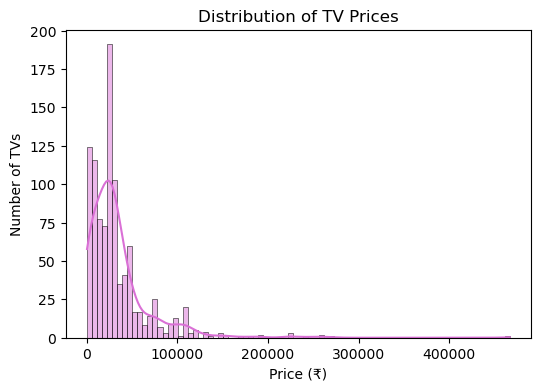

In [78]:
#Histplot
plt.figure(figsize=(6,4))
sns.histplot(tv['Price(₹)'],kde=True,color="orchid")
plt.xlabel('Price (₹)')
plt.ylabel('Number of TVs')
plt.title('Distribution of TV Prices')
plt.show()

**Observations:**
- Most TVs are concentrated in the lower to mid price range.
- The price distribution is right-skewed, with only a few very expensive TVs.
- A few high-priced TVs contribute to the right skewness of the distribution.

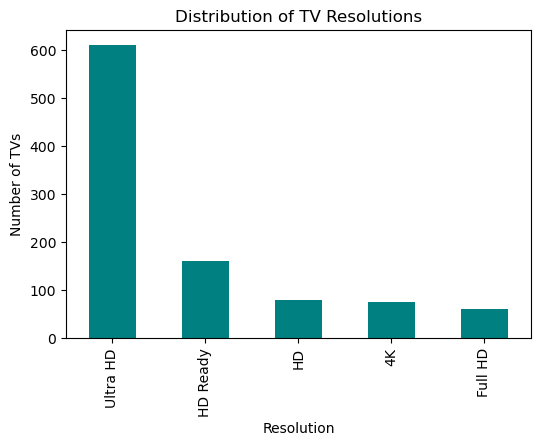

In [40]:
#Bar Plot
plt.figure(figsize=(6,4))
tv['Resolution'].value_counts().plot(kind='bar', color='teal')
plt.xlabel('Resolution')
plt.ylabel('Number of TVs')
plt.title('Distribution of TV Resolutions')
plt.show()

**Observations:**
- Ultra HD TVs have the highest count in the dataset.
- HD and Full HD models are fewer compared to Ultra HD TVs.
- The distribution of TV resolutions is uneven across categories.

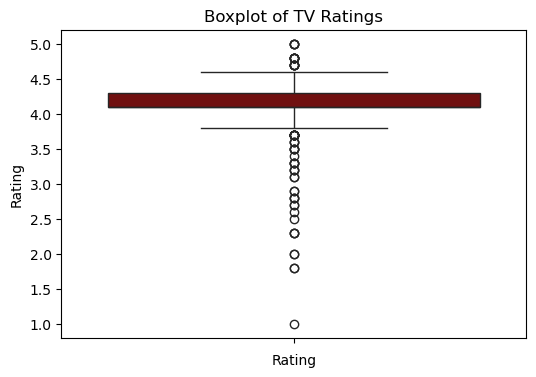

In [41]:
#Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(tv['Rating'],color="maroon")
plt.xlabel('Rating')
plt.title('Boxplot of TV Ratings')
plt.show()

**Observation:**
- Most TV ratings are clustered around 4,suggesting generally positive ratings.
- The spread of ratings is relatively narrow.
- A few low-rating outliers are visible in the dataset.

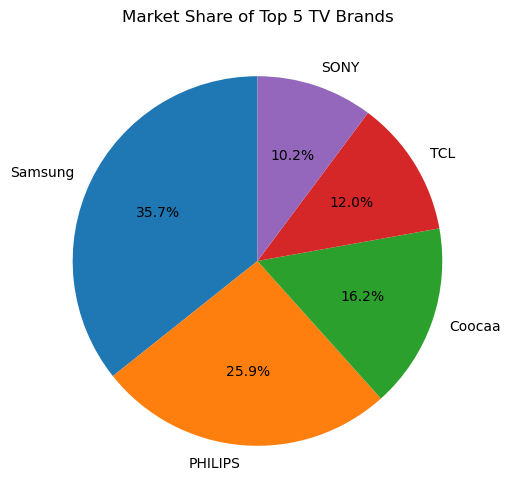

In [43]:
#Pie Chart
plt.figure(figsize=(6,6))
tv['Brand'].value_counts().head(5).plot(kind='pie',autopct='%1.1f%%',startangle=90)
plt.title('Market Share of Top 5 TV Brands')
plt.ylabel('')
plt.show()

**Observations:**
- Samsung has the highest market share among the top 5 brands.
- Philips has the second highest market share among the top 5 brands.
- Sony has the lowest market share among the top 5 brands.

## **2.Bivariate Analysis**

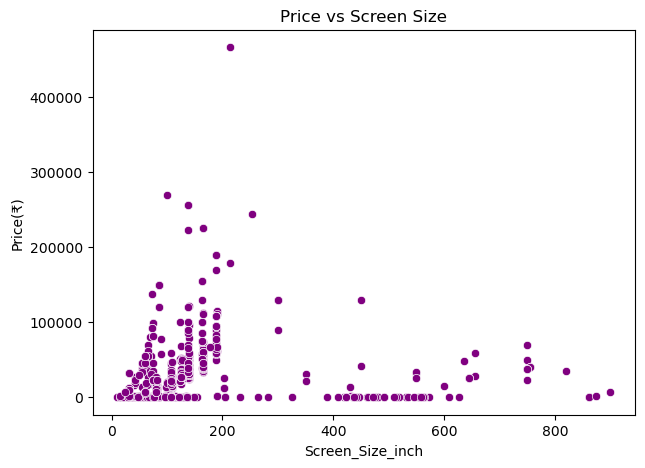

In [44]:
#Scatterplot
plt.figure(figsize=(7,5))
sns.scatterplot(data=tv, x="Screen_Size_inch", y="Price(₹)",color="purple")
plt.title("Price vs Screen Size")
plt.show()

**Observations:**
- There is a positive relationship between screen size and price, but the relationship is not very strong.
- Most TVs are concentrated in the lower screen-size range with relatively lower prices.
- There are significant price variations even among TVs with similar screen sizes.

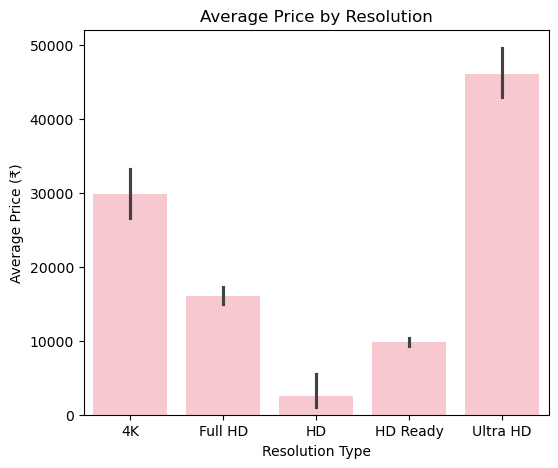

In [45]:
#Barplot
plt.figure(figsize=(6,5))
sns.barplot(data=tv, x="Resolution", y="Price(₹)",color='pink')
plt.title("Average Price by Resolution")
plt.xlabel("Resolution Type")
plt.ylabel("Average Price (₹)")
plt.show()

**Observations:**
- Higher resolution TVs generally have higher average prices. Ultra HD has the highest average price, followed by 4K, while HD and HD Ready have lower average prices.
- HD and HD Ready TVs have the lowest average prices among the resolution types..These resolutions show much lower average prices, indicating their suitability for budget-conscious consumers.
- Price variation appears higher for Ultra HD and 4K TVs, as shown by the larger error bars.

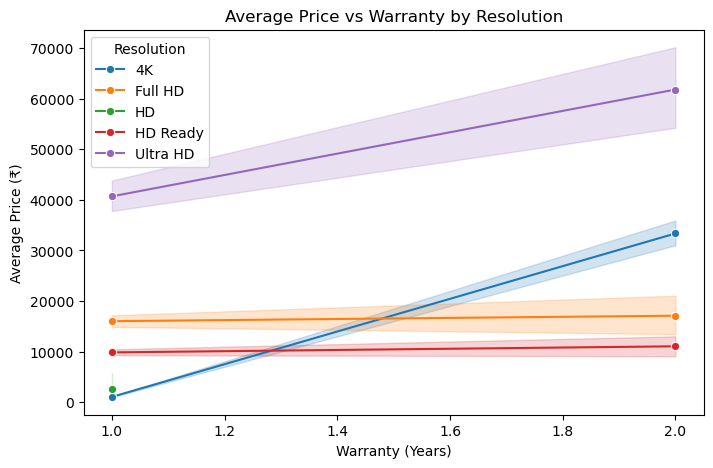

In [47]:
#Lineplot
plt.figure(figsize=(8,5))
sns.lineplot(data=tv,x="Warranty",y="Price(₹)",hue="Resolution",estimator="mean",marker="o")
plt.title("Average Price vs Warranty by Resolution")
plt.xlabel("Warranty (Years)")
plt.ylabel("Average Price (₹)")
plt.show()

**Observations:**
- Premium resolutions (Ultra HD and 4K) show a clear upward trend” when warranty extends from 1 to 2 years.
- For budget resolutions (HD and HD Ready), increasing warranty has limited price variation on price.
- longer warranty is associated with higher average prices mainly to high-end TVs, indicating that extended warranty is a premium feature rather than a budget driver.

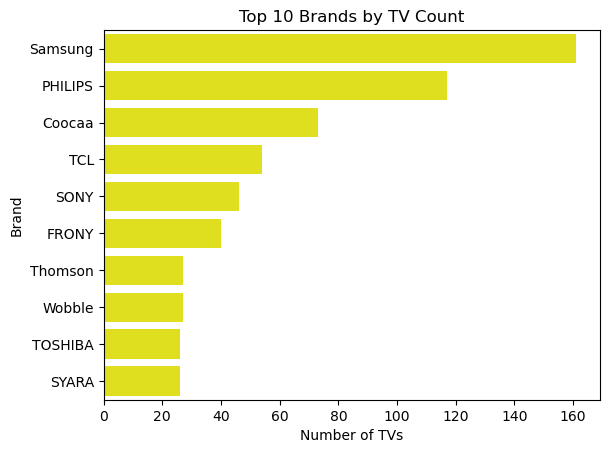

In [48]:
#Countplot
sns.countplot(y=tv["Brand"],order=tv["Brand"].value_counts().head(10).index,color="YELLOW")
plt.xlabel("Number of TVs")
plt.ylabel("Brand")
plt.title("Top 10 Brands by TV Count")
plt.show()

**Observations:**
- Samsung has the highest number of TV listings among all brands.
- Philips ranks second, followed by Coocaa and TCL.
- Sony and other brands have moderate presence.
- The remaining brands show comparatively lower counts, indicating uneven brand distribution in the market.

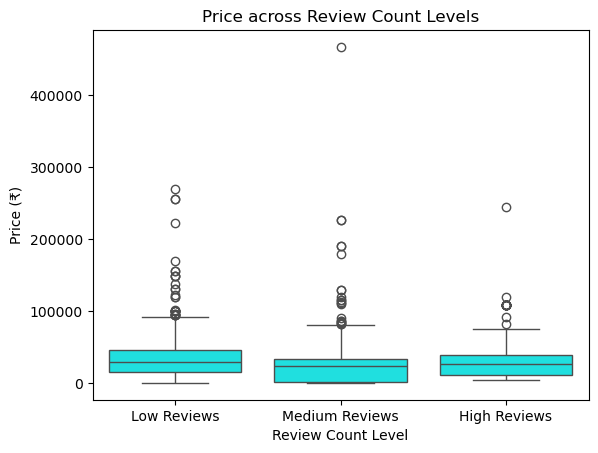

In [49]:
#Boxplot
tv["Review_Level"] = pd.qcut(tv["no_of_Reviews"],q=3,labels=["Low Reviews", "Medium Reviews", "High Reviews"])
sns.boxplot(x=tv["Review_Level"],y=tv["Price(₹)"],color="aqua")
plt.xlabel("Review Count Level")
plt.ylabel("Price (₹)")
plt.title("Price across Review Count Levels")
plt.show()

**Observations:**
- Median prices are relatively similar across Low, Medium, and High review categories.
- Low-review TVs show a slightly wider price spread with more extreme outliers.
- Medium and High review TVs show somewhat more concentrated pricing ranges.
- There is no strong direct relationship between number of reviews and price level.

# **3.Multivariate Analysis**

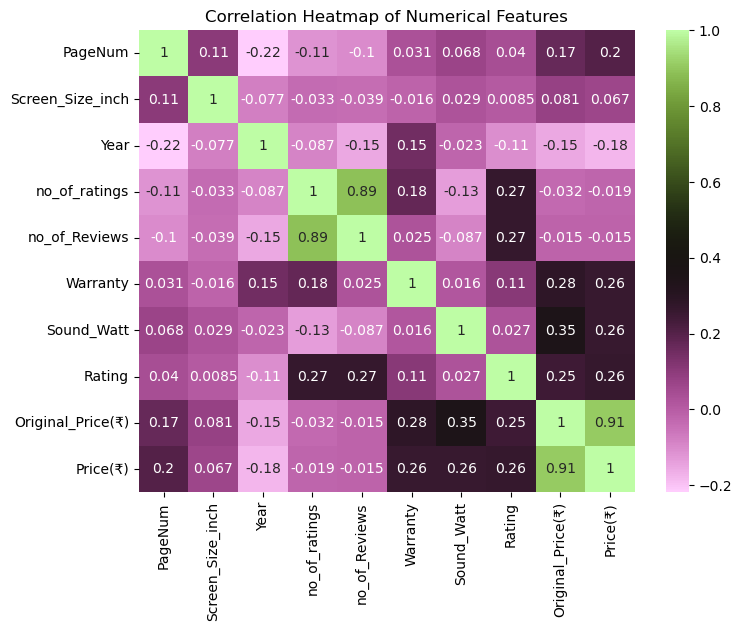

In [50]:
#Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(tv.select_dtypes(include = ["int64","float64"]).corr(),annot = True,cmap = "vanimo")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Observation:**
- Price is strongly positively correlated with Original Price.
- Number of ratings and number of reviews show a strong positive correlation.
- Price has a weak positive correlation with rating.
- Warranty shows a weak positive correlation with price.

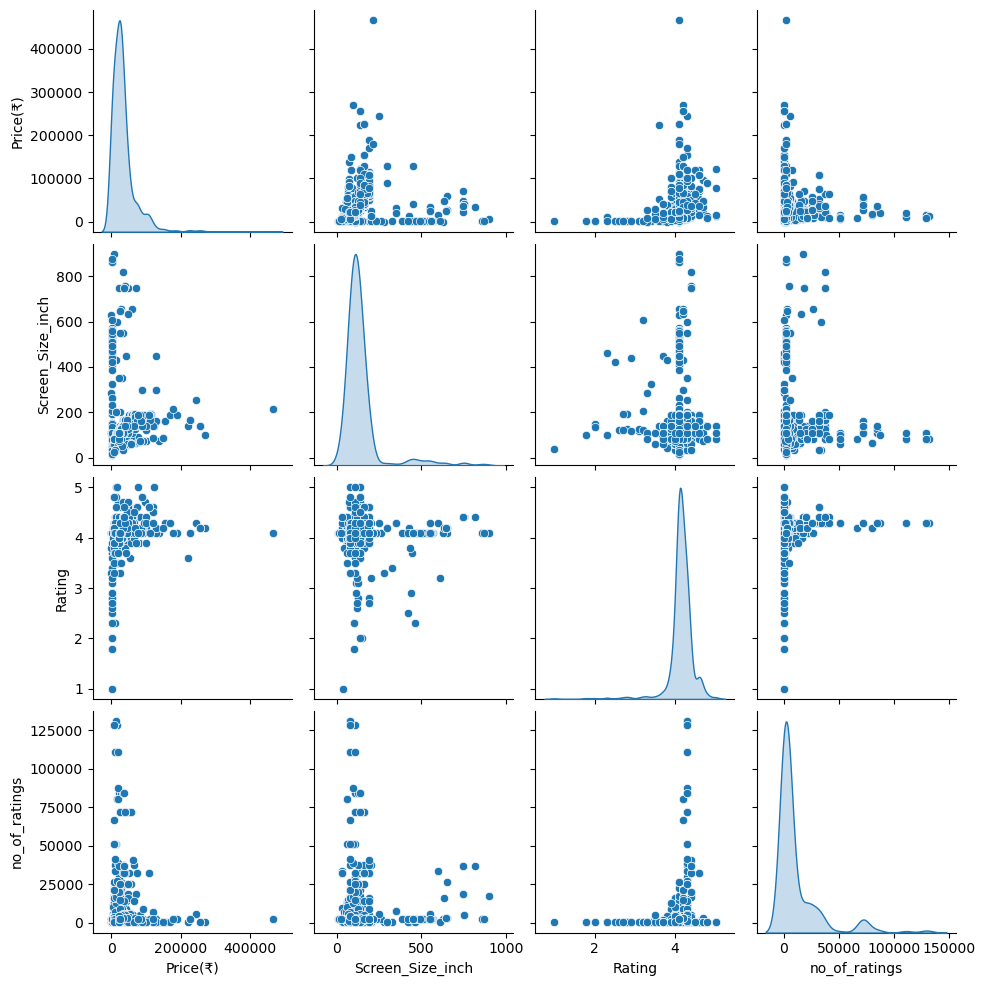

In [51]:
#pair plot
pair_cols = ["Price(₹)","Screen_Size_inch","Rating","Discount(%)","no_of_ratings"]
sns.pairplot(tv[pair_cols],diag_kind="kde")
plt.show()

**Observations:**
- Price distribution is highly right-skewed with a few extreme high-price outliers.
- Screen size has a weak to moderate positive relationship with price.
- Ratings are concentrated between 3.5 and 4.5, indicating generally positive feedback.
- No strong linear relationship is observed between rating score and number of ratings.

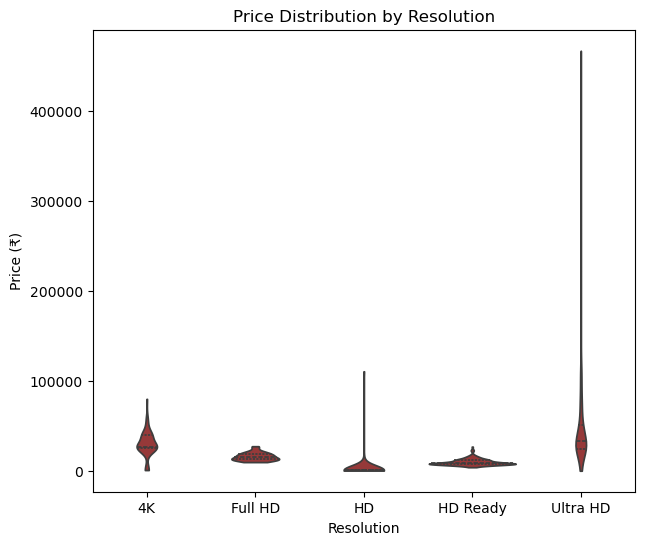

In [52]:
#Violinplot
plt.figure(figsize=(7,6))
sns.violinplot(data=tv,x="Resolution",y="Price(₹)",inner="quartile",color="brown",cut=0)
plt.xlabel("Resolution")
plt.ylabel("Price (₹)")
plt.title("Price Distribution by Resolution")
plt.show()

**Observations:**
- Ultra HD TVs show the highest price levels and widest variability.
- HD Ready TVs are concentrated in the lower price range.
- 4K TVs exhibit moderate price dispersion with some higher-priced models.
- Full HD TVs are positioned mainly in the mid-price segment with relatively stable pricing.

### **Key Observations**

- TV price is mainly driven by resolution, with Ultra HD and 4K models priced significantly higher than HD variants.
- Screen size alone does not determine price, as TVs of similar size show wide price variation due to brand and features.
- Higher-priced TVs receive larger discounts, indicating strategic discounting for premium products.
- Most TVs fall in the low-to-mid price range, showing that demand is concentrated in affordable segments.
- Number of ratings and number of reviews are strongly correlated, making them reliable indicators of product popularity.
- Highly reviewed TVs show more stable pricing, suggesting better market acceptance and trust.
- Customer ratings are generally high and clustered, indicating overall positive user satisfaction across brands.
- Extended warranty impacts price mainly for premium TVs, not for budget models

### **Final Insight**

TV pricing is driven more by resolution and pricing strategy than by screen size, with most consumer demand concentrated in affordable models while premium TVs rely on discounts to attract buyers.